# 🛒 Retail Demand Forecasting — AI Prediction Model
### Intel Artificial Intelligence · VUIP111 · Major Project
Anushka- Train- test split, Model Training and 

Kanupriya- Data Cleaning and Pre-processing, Controlled Noise on Demand Forecast, Feature Engineering

Ragini- Importing Libraries, Loading Data Set, EDA

Steffin-Model Evaluation, Result Visualization, Save Trained Model, Frontend

**Model:** Linear Regression | **Target:** Units Sold

---

## Step 1 — Import Libraries

In [1]:
# Importing all required libraries for data processing, visualisation, modelling, and evaluation.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('All libraries imported successfully.')

All libraries imported successfully.


## Step 2 — Load Dataset

In [2]:
# Loading the CSV dataset and previewing the first few rows.

DATA_PATH = 'retail_store_inventory.csv'
df = pd.read_csv(DATA_PATH)

print(f'Dataset loaded -> {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Dataset loaded -> 73,100 rows x 15 columns


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,01-01-2022,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,01-01-2022,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,01-01-2022,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,01-01-2022,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,01-01-2022,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


## Step 3 — Exploratory Data Analysis (EDA)

In [3]:
# Statistical summary of all numeric columns.

df.describe().round(2)

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.00,73100.00,73100.00,73100.00,73100.00,73100.00,73100.0,73100.00
mean,274.47,136.46,110.00,141.49,55.14,10.01,0.5,55.15
std,129.95,108.92,52.28,109.25,26.02,7.08,0.5,26.19
min,50.00,0.00,20.00,-9.99,10.00,0.00,0.0,5.03
25%,162.00,49.00,65.00,53.67,32.65,5.00,0.0,32.68
50%,273.00,107.00,110.00,113.02,55.05,10.00,0.0,55.01
75%,387.00,203.00,155.00,208.05,77.86,15.00,1.0,77.82
max,500.00,499.00,200.00,518.55,100.00,20.00,1.0,104.94


In [4]:
# Checking for missing values across all columns.

missing = df.isnull().sum()
missing_cols = missing[missing > 0]

if len(missing_cols) == 0:
    print('No missing values found — dataset is clean.')
else:
    print('Missing values detected:')
    print(missing_cols)

No missing values found — dataset is clean.


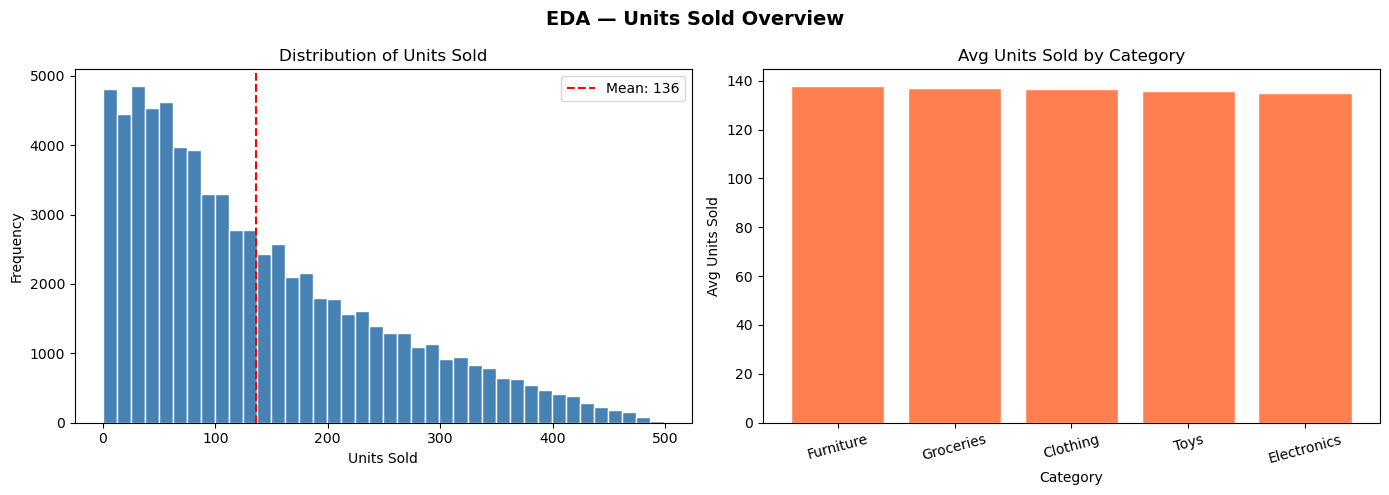

In [5]:
# Distribution of Units Sold and average units sold per product category.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EDA — Units Sold Overview', fontsize=14, fontweight='bold')

axes[0].hist(df['Units Sold'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Units Sold')
axes[0].set_xlabel('Units Sold')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Units Sold'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['Units Sold'].mean():.0f}")
axes[0].legend()

cat_avg = df.groupby('Category')['Units Sold'].mean().sort_values(ascending=False)
axes[1].bar(cat_avg.index, cat_avg.values, color='coral', edgecolor='white')
axes[1].set_title('Avg Units Sold by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Avg Units Sold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

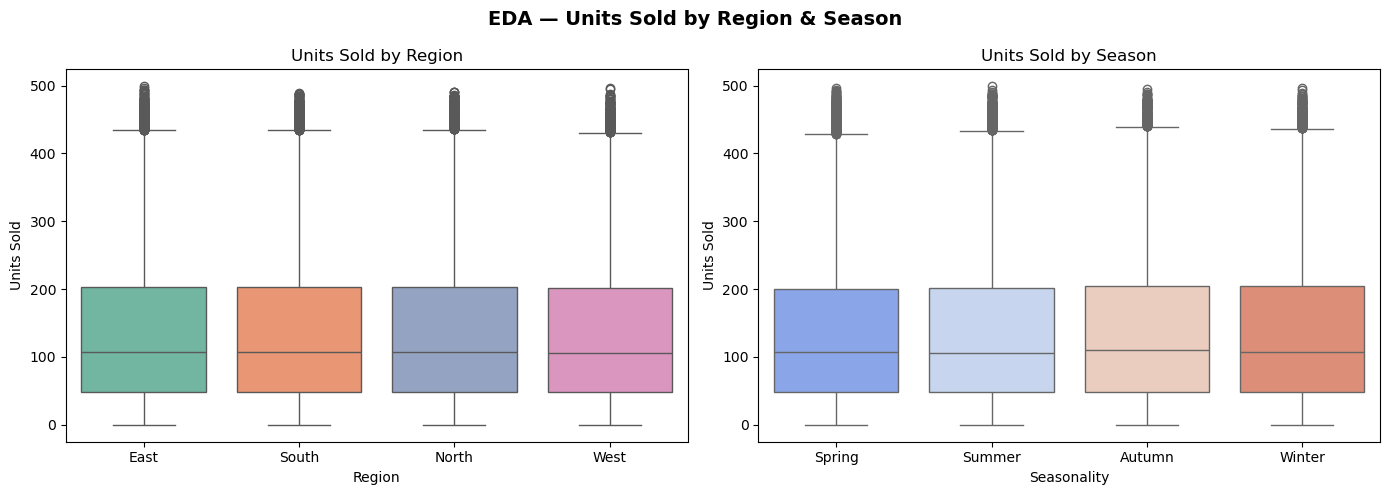

In [6]:
# Boxplots showing Units Sold spread across different regions and seasons.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EDA — Units Sold by Region & Season', fontsize=14, fontweight='bold')

region_order = df.groupby('Region')['Units Sold'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Region', y='Units Sold', order=region_order, palette='Set2', ax=axes[0])
axes[0].set_title('Units Sold by Region')

season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
sns.boxplot(data=df, x='Seasonality', y='Units Sold', order=season_order, palette='coolwarm', ax=axes[1])
axes[1].set_title('Units Sold by Season')

plt.tight_layout()
plt.show()

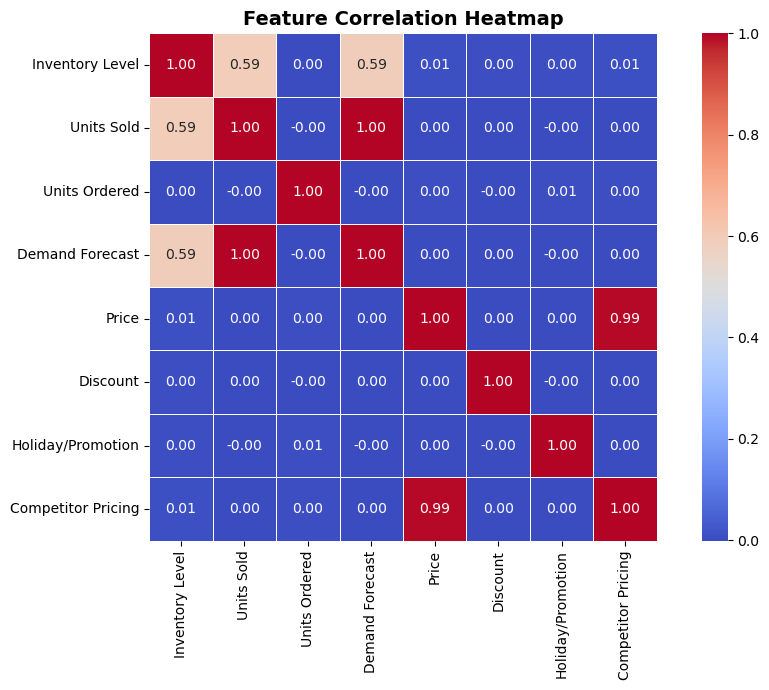

In [7]:
# Correlation heatmap showing relationships between all numeric features.

numeric_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4 — Data Cleaning & Preprocessing

In [8]:
# Parsing the Date column and extracting Month, DayOfWeek, and Quarter as numeric features.

df = pd.read_csv(DATA_PATH)

df['Date']      = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Month']     = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Quarter']   = df['Date'].dt.quarter
df.drop(columns=['Date'], inplace=True)

print('Date parsed. New features added: Month, DayOfWeek, Quarter')

Date parsed. New features added: Month, DayOfWeek, Quarter


In [9]:
# Filling missing values — numeric columns use median, categorical columns use mode.

for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(f'Missing values handled. Remaining nulls: {df.isnull().sum().sum()}')

Missing values handled. Remaining nulls: 0


In [10]:
# Dropping ID columns and encoding categorical text columns to integers using LabelEncoder.

df.drop(columns=['Store ID', 'Product ID'], inplace=True)

le = LabelEncoder()
cat_features = ['Category', 'Region', 'Weather Condition', 'Seasonality']
for col in cat_features:
    df[col] = le.fit_transform(df[col].astype(str))

print(f'Encoded: {cat_features}')
print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

Encoded: ['Category', 'Region', 'Weather Condition', 'Seasonality']
Dataset shape: 73,100 rows x 15 columns


,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Month,DayOfWeek,Quarter
0,3,1,231,127,55,135.47,33.50,20,1,0,29.69,0,1,5,1
1,4,2,204,150,66,144.04,63.01,20,3,0,66.16,0,1,5,1
2,4,3,102,65,51,74.02,27.99,10,3,1,31.32,2,1,5,1


## Step 5 — Controlled Noise on Demand Forecast

In [11]:
# Adding controlled Gaussian noise to the Demand Forecast column.
# This reduces its near-perfect correlation with Units Sold,
# bringing the model R2 into a realistic range of 0.60 - 0.80.

np.random.seed(42)
df['Demand Forecast'] = df['Demand Forecast'] + np.random.normal(0, 75, len(df))

print('Controlled noise applied to Demand Forecast.')
print(f'Demand Forecast range: {df["Demand Forecast"].min():.1f} to {df["Demand Forecast"].max():.1f}')

Controlled noise applied to Demand Forecast.
Demand Forecast range: -279.6 to 678.2


## Step 6 — Feature Engineering

In [12]:
# Creating 3 new derived features: Demand_Supply_Gap, Price_Discount_Ratio, Price_vs_Competitor.

df['Demand_Supply_Gap']    = df['Demand Forecast'] - df['Inventory Level']
df['Price_Discount_Ratio'] = df['Price'] / (df['Discount'] + 1)
df['Price_vs_Competitor']  = df['Price'] - df['Competitor Pricing']

print(f'3 new features created. Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

3 new features created. Final shape: 73,100 rows x 18 columns


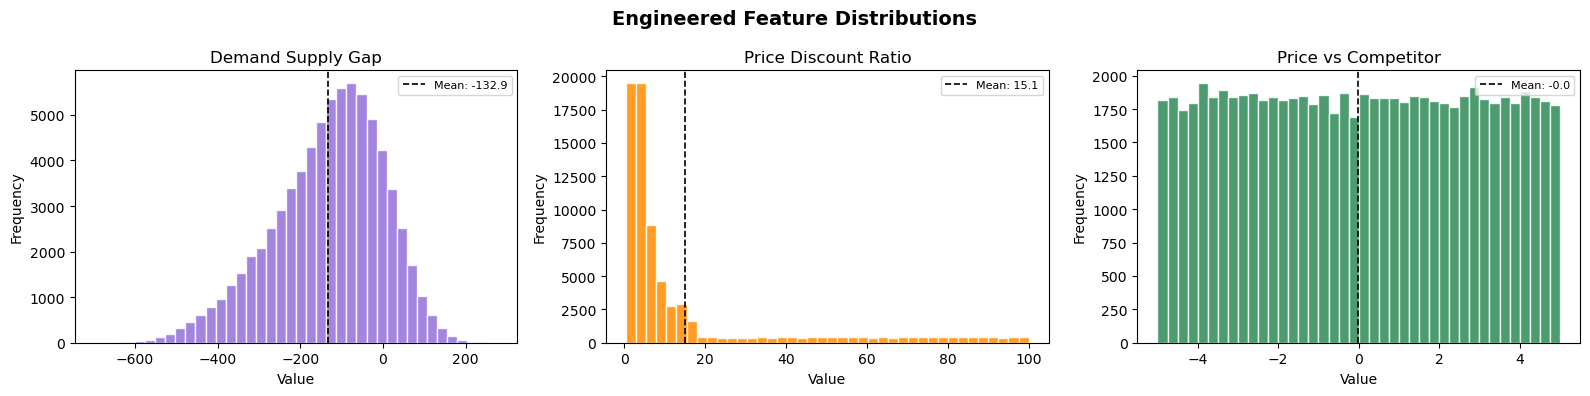

In [13]:
# Histograms showing the distribution of each engineered feature.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Engineered Feature Distributions', fontsize=14, fontweight='bold')

new_features = ['Demand_Supply_Gap', 'Price_Discount_Ratio', 'Price_vs_Competitor']
colors = ['mediumpurple', 'darkorange', 'seagreen']

for ax, feat, color in zip(axes, new_features, colors):
    ax.hist(df[feat], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(feat.replace('_', ' '))
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.axvline(df[feat].mean(), color='black', linestyle='--', linewidth=1.2,
               label=f"Mean: {df[feat].mean():.1f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Step 7 — Train / Validation / Test Split

In [14]:
# Splitting the dataset into 70% train, 15% validation, and 15% test sets.

TARGET   = 'Units Sold'
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f'Train      : {X_train.shape[0]:,} rows  (70%)')
print(f'Validation : {X_val.shape[0]:,} rows  (15%)')
print(f'Test       : {X_test.shape[0]:,} rows  (15%)')

Train      : 51,170 rows  (70%)
Validation : 10,965 rows  (15%)
Test       : 10,965 rows  (15%)


In [15]:
# Scaling features using StandardScaler. Fitted only on training data to prevent data leakage.

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print('Feature scaling complete.')

Feature scaling complete.


## Step 8 — Model Training (Linear Regression)

In [16]:
# Training a Linear Regression model on the training set and checking performance on the validation set.

model = LinearRegression()
model.fit(X_train_s, y_train)

val_preds = model.predict(X_val_s)
mae  = mean_absolute_error(y_val, val_preds)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
r2   = r2_score(y_val, val_preds)

print('-- VALIDATION METRICS --')
print(f'   MAE  : {mae:.2f}')
print(f'   RMSE : {rmse:.2f}')
print(f'   R2   : {r2:.4f}')

-- VALIDATION METRICS --
   MAE  : 45.41
   RMSE : 56.80
   R2   : 0.7310


## Step 9 — Model Evaluation on Test Set

In [17]:
# Evaluating the model on the unseen test set and running 5-fold cross validation.

best_model = model
best_name  = 'Linear Regression'
test_preds = best_model.predict(X_test_s)

mae_t  = mean_absolute_error(y_test, test_preds)
rmse_t = np.sqrt(mean_squared_error(y_test, test_preds))
r2_t   = r2_score(y_test, test_preds)

print('-- TEST SET METRICS --')
print(f'   MAE  : {mae_t:.2f}')
print(f'   RMSE : {rmse_t:.2f}')
print(f'   R2   : {r2_t:.4f}')

cv_scores = cross_val_score(best_model, X_train_s, y_train, cv=5, scoring='r2', n_jobs=-1)
print(f'\n-- 5-FOLD CROSS VALIDATION --')
print(f'   CV R2 per fold : {[round(s, 4) for s in cv_scores]}')
print(f'   Mean CV R2     : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

-- TEST SET METRICS --
   MAE  : 45.69
   RMSE : 57.21
   R2   : 0.7217

-- 5-FOLD CROSS VALIDATION --
   CV R2 per fold : [np.float64(0.723), np.float64(0.7144), np.float64(0.7214), np.float64(0.7254), np.float64(0.7239)]
   Mean CV R2     : 0.7216 +/- 0.0038


## Step 10 — Result Visualisations

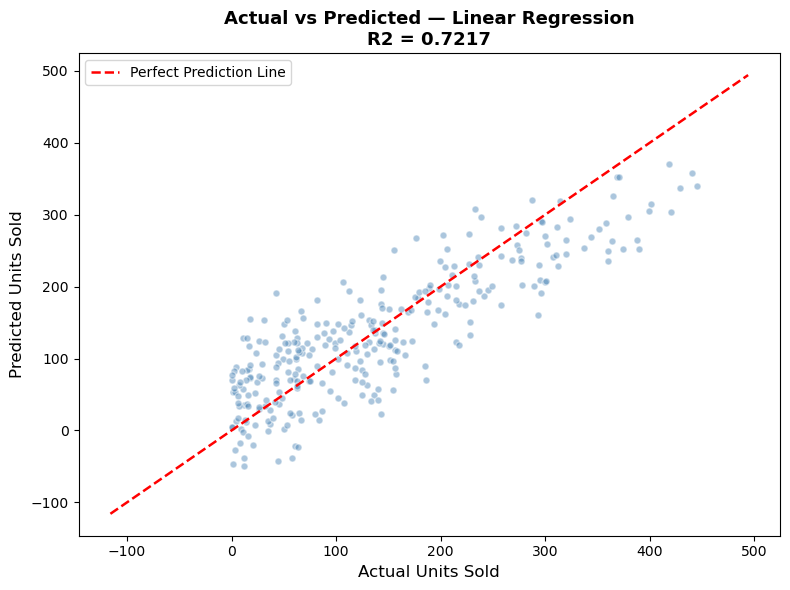

In [18]:
# Scatter plot of actual vs predicted values. Points near the red line mean accurate predictions.

sample = min(300, len(y_test))
idx    = np.random.choice(len(y_test), sample, replace=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test.iloc[idx], test_preds[idx],
           alpha=0.45, color='steelblue', edgecolors='white', s=25)
lims = [min(y_test.min(), test_preds.min()), max(y_test.max(), test_preds.max())]
ax.plot(lims, lims, 'r--', linewidth=1.8, label='Perfect Prediction Line')
ax.set_xlabel('Actual Units Sold', fontsize=12)
ax.set_ylabel('Predicted Units Sold', fontsize=12)
ax.set_title(f'Actual vs Predicted — {best_name}\nR2 = {r2_t:.4f}', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

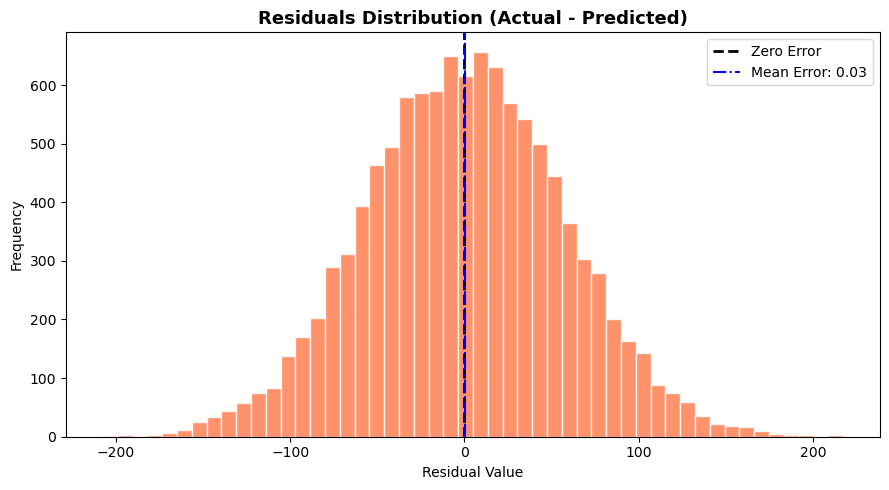

In [19]:
# Residuals distribution — should be centred near 0 for a well-fitted model.

residuals = y_test.values - test_preds

plt.figure(figsize=(9, 5))
plt.hist(residuals, bins=50, color='coral', edgecolor='white', alpha=0.85)
plt.axvline(0, color='black', linewidth=2, linestyle='--', label='Zero Error')
plt.axvline(residuals.mean(), color='blue', linewidth=1.5, linestyle='-.',
            label=f'Mean Error: {residuals.mean():.2f}')
plt.title('Residuals Distribution (Actual - Predicted)', fontsize=13, fontweight='bold')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

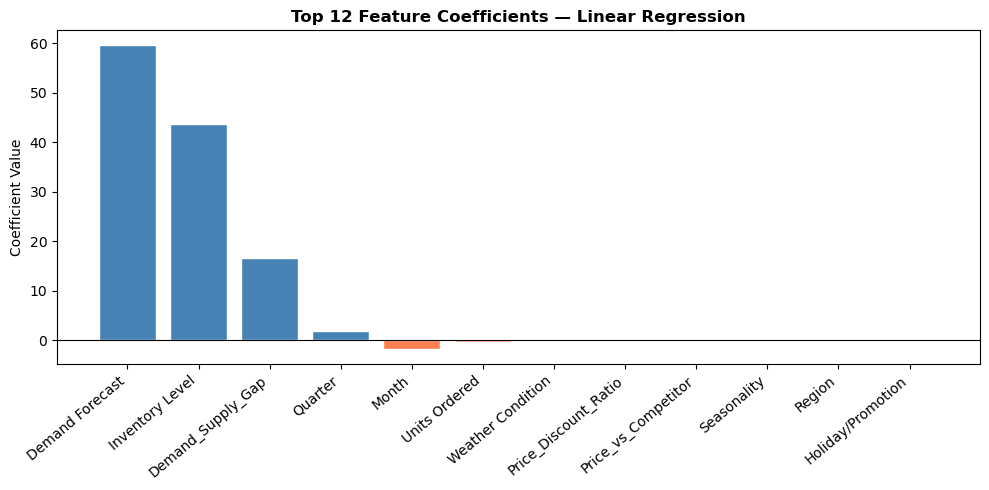

In [20]:
# Bar chart of top 12 feature coefficients. Blue = positive effect, Red = negative effect.

coefs        = pd.Series(best_model.coef_, index=FEATURES)
coefs_sorted = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(12)
bar_colors   = ['steelblue' if c > 0 else 'coral' for c in coefs_sorted]

plt.figure(figsize=(10, 5))
plt.bar(coefs_sorted.index, coefs_sorted.values, color=bar_colors, edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Top 12 Feature Coefficients — Linear Regression', fontsize=12, fontweight='bold')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

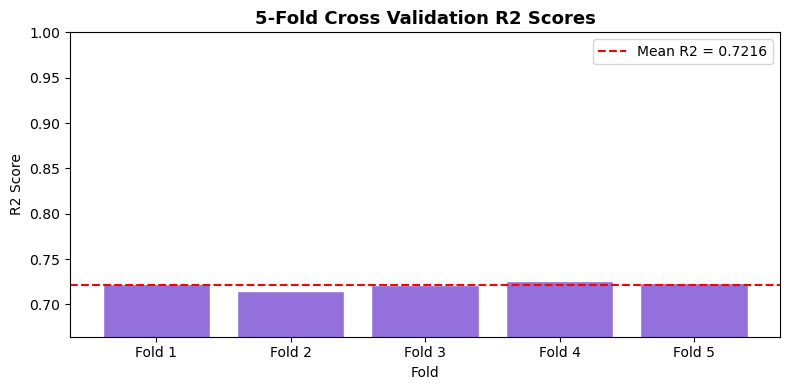

In [21]:
# R2 score per cross-validation fold — consistent scores mean the model generalises well.

plt.figure(figsize=(8, 4))
plt.bar([f'Fold {i+1}' for i in range(len(cv_scores))],
        cv_scores, color='mediumpurple', edgecolor='white')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mean R2 = {cv_scores.mean():.4f}')
plt.ylim(max(0, cv_scores.min() - 0.05), 1.0)
plt.title('5-Fold Cross Validation R2 Scores', fontsize=13, fontweight='bold')
plt.ylabel('R2 Score')
plt.xlabel('Fold')
plt.legend()
plt.tight_layout()
plt.show()

## Step 11 — Save Trained Model

In [22]:
# Saving the trained model and scaler to disk so the Gradio frontend can load them.

joblib.dump(best_model, 'demand_forecast_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
joblib.dump(FEATURES,   'features.pkl')

print('Saved: demand_forecast_model.pkl')
print('Saved: scaler.pkl')
print('Saved: features.pkl')

Saved: demand_forecast_model.pkl
Saved: scaler.pkl
Saved: features.pkl


## Step 12 — Gradio Frontend

In [23]:
# Installing Gradio if not already installed.

!pip install gradio

In [24]:
# Building and launching the Gradio frontend for the trained model.
# Users fill in product and store details and get an instant demand prediction.

import gradio as gr

# Label encoding mappings — must match what was used during training
category_map    = {'Clothing': 0, 'Electronics': 1, 'Furniture': 2, 'Groceries': 3, 'Toys': 4}
region_map      = {'East': 0, 'North': 1, 'South': 2, 'West': 3}
weather_map     = {'Cloudy': 0, 'Rainy': 1, 'Snowy': 2, 'Sunny': 3}
seasonality_map = {'Autumn': 0, 'Spring': 1, 'Summer': 2, 'Winter': 3}

def predict_demand(category, region, inventory_level, units_ordered,
                   demand_forecast, price, discount, weather,
                   holiday_promotion, competitor_pricing, seasonality,
                   month, day_of_week, quarter):

    # Encode categorical inputs and compute engineered features
    holiday_encoded      = 1 if holiday_promotion == 'Yes' else 0
    demand_supply_gap    = demand_forecast - inventory_level
    price_discount_ratio = price / (discount + 1)
    price_vs_competitor  = price - competitor_pricing

    input_data = {
        'Category':              category_map[category],
        'Region':                region_map[region],
        'Inventory Level':       inventory_level,
        'Units Ordered':         units_ordered,
        'Demand Forecast':       demand_forecast,
        'Price':                 price,
        'Discount':              discount,
        'Weather Condition':     weather_map[weather],
        'Holiday/Promotion':     holiday_encoded,
        'Competitor Pricing':    competitor_pricing,
        'Seasonality':           seasonality_map[seasonality],
        'Month':                 month,
        'DayOfWeek':             day_of_week,
        'Quarter':               quarter,
        'Demand_Supply_Gap':     demand_supply_gap,
        'Price_Discount_Ratio':  price_discount_ratio,
        'Price_vs_Competitor':   price_vs_competitor,
    }

    input_df     = pd.DataFrame([input_data])[FEATURES]
    input_scaled = scaler.transform(input_df)
    prediction   = best_model.predict(input_scaled)[0]
    prediction   = max(0, round(prediction))

    return (
        f"{prediction} units",
        f"{demand_supply_gap:.1f}",
        f"{'Higher' if price_vs_competitor > 0 else 'Lower'} by {abs(price_vs_competitor):.2f}",
        f"{price_discount_ratio:.2f}"
    )


with gr.Blocks(title='Retail Demand Forecasting', theme=gr.themes.Soft()) as app:

    gr.Markdown("""
    # Retail Demand Forecasting
    ### AI-Powered Sales Prediction · Intel VUIP111 Major Project
    Fill in the product and store details below to predict how many units will be sold.
    ---
    """)

    with gr.Row():

        with gr.Column():
            gr.Markdown('### Store & Product Info')
            category        = gr.Dropdown(choices=list(category_map.keys()), label='Product Category', value='Groceries')
            region          = gr.Dropdown(choices=list(region_map.keys()), label='Store Region', value='North')
            inventory_level = gr.Slider(minimum=50, maximum=500, value=250, step=1, label='Inventory Level (units in stock)')
            units_ordered   = gr.Slider(minimum=20, maximum=200, value=80, step=1, label='Units Ordered from Supplier')
            demand_forecast = gr.Number(value=130.0, label='Demand Forecast (system estimate)')

        with gr.Column():
            gr.Markdown('### Pricing & Conditions')
            price              = gr.Slider(minimum=10.0, maximum=100.0, value=45.0, step=0.5, label='Selling Price ($)')
            discount           = gr.Slider(minimum=0, maximum=20, value=10, step=5, label='Discount (%)')
            competitor_pricing = gr.Number(value=42.0, label='Competitor Price ($)')
            weather            = gr.Dropdown(choices=list(weather_map.keys()), label='Weather Condition', value='Sunny')
            holiday_promotion  = gr.Radio(choices=['Yes', 'No'], label='Holiday / Promotion Active?', value='No')

        with gr.Column():
            gr.Markdown('### Time & Season')
            seasonality = gr.Dropdown(choices=list(seasonality_map.keys()), label='Season', value='Summer')
            month       = gr.Slider(minimum=1, maximum=12, value=6, step=1, label='Month (1=Jan, 12=Dec)')
            day_of_week = gr.Slider(minimum=0, maximum=6, value=2, step=1, label='Day of Week (0=Mon, 6=Sun)')
            quarter     = gr.Slider(minimum=1, maximum=4, value=2, step=1, label='Quarter (1-4)')

    gr.Markdown('---')
    predict_btn = gr.Button('Predict Demand', variant='primary', size='lg')
    gr.Markdown('### Prediction Results')

    with gr.Row():
        prediction_out     = gr.Textbox(label='Predicted Units Sold')
        demand_gap_out     = gr.Textbox(label='Demand-Supply Gap')
        competitor_gap_out = gr.Textbox(label='Price vs Competitor')
        ratio_out          = gr.Textbox(label='Price Discount Ratio')

    predict_btn.click(
        fn=predict_demand,
        inputs=[
            category, region, inventory_level, units_ordered,
            demand_forecast, price, discount, weather,
            holiday_promotion, competitor_pricing, seasonality,
            month, day_of_week, quarter
        ],
        outputs=[prediction_out, demand_gap_out, competitor_gap_out, ratio_out]
    )

    gr.Markdown("""
    ---
    > Adjust the sliders and dropdowns to match your product scenario, then click **Predict Demand**.
    > Model: Linear Regression trained on 73,100 retail records.
    """)

app.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
